In [230]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns
import seaborn.objects as so

from collections import Counter

Preparation

In [231]:
from pathlib import Path

data_path = Path("results-survey558834_completed.csv")
full_data = pd.read_csv(data_path, low_memory=False)

annotations_path = Path("task2_passfail.csv")
annotations_data = pd.read_csv(annotations_path, low_memory=False)

# ignorieren von failed attantion checks
full_data = full_data[
    ~full_data["Please paste your Prolific ID here:"]
    .astype(str)
    .isin(["668d382ea3dc675995db9ca9", "697cf77974b398d960ae50a0", "697a4bca3a9b41997e03bdaf"])
]

annotations_data = annotations_data[
    ~annotations_data["Response ID"]
    .astype(str)
    .isin(["47", "52", "72"])
]

colours = [ "#ff7e8dff", "#7fccff", "#a7b3b9","#e2001a", "#0271bb", "#3b515b",  "#FFFFFF"]
blue_colours = ["#0271bb", "#1b7fc1", "#4d9bcf", "#67a9d6", "#80b8dd", "#99c6e3", "#b3d4ea", "#cce2f1", "#e5f0f8", "#ffffff"]
uhhpalette = sns.set_palette(sns.color_palette(colours))
sns.set_style("darkgrid")
# plt.figure(figsize=(8, 4))


In [232]:
#renaming of all relevant columns for easier access
# First, clean column names by replacing non-breaking spaces with regular spaces
full_data.columns = full_data.columns.str.replace('\u00a0', ' ', regex=False)

full_data = full_data.rename(columns={

    # --- meta / screening ---
    'In broad terms, what is your task?': 'attention_check_01',
    '{if(is_empty(check),rand(1,2),check)}': 'condition',

    # --- demographics ---
    'Please select your gender.': 'gender',
    'Please enter your age.': 'age',
    'Please enter your current occupation title. If you are unemployed, please enter the title of your last occupation.': 'occupation',
    'Please enter the amount of experience you have in your current occupation (or, if unemployed, your last occupation) in YEARS.': 'experience_years',
    'On a scale from 1 (= very low) to 5 (=very high), how would you rate your affinity with technology?': 'tech_affinity',

    # --- prior experience ---
    'Have you ever worked with crisis maps or GIS (geographic information systems) before?   If so, which ones have you used?  Please enter their names into the comment field. ': 'gis_experience',
    'Have you ever worked with crisis maps or GIS (geographic information systems) before?   If so, which ones have you used?  Please enter their names into the comment field.  [Comment]': 'gis_experience_comment',
    'Have you ever worked during an emergency such as a storm surge, hurricane or terrorist attack? If so, please briefly describe your experience below.      If you have no such experience, you may leave the input field blank. ': 'emergency_experience',

    # --- task 1 ---
    'There is currently an evacuation going on somewhere in Hamburg. The chief of police needs to know where!  When asked for details, she provides you with the name of the evacuation incident: "Castle on Fire!".     On the map below, pinpoint where this incident is taking place. Your selection is valid as long as the coordinates are roughly within those of the evacuation zone. ': 'task1_location',
    'On a scale from 1 (="very easy") to 5 (="very difficult"), how difficult did you find the task?': 'task1_difficulty',
    'Do you have any feedback regarding this task? (optional)': 'task1_feedback',

    # --- task 2 ---
    'Your department receives an urgent call: A part of the riverbank has been flooded! Create one incident of category "flooding" affecting an "area" anywhere on the map. Set its priority to “Low” and its status to "Units requested".Please upload a screenshot of your newly created incident with the pop-up opened and sidebar visible.': 'task2_upload',
    'filecount - Your department receives an urgent call: A part of the riverbank has been flooded! Create one incident of category "flooding" affecting an "area" anywhere on the map. Set its priority to “Low” and its status to "Units requested".Please upload a screenshot of your newly created incident with the pop-up opened and sidebar visible.': 'task2_filecount',
    'On a scale from 1 (="very easy") to 5 (="very difficult"), how difficult did you find the task?.1': 'task2_difficulty',
    'Do you have any feedback regarding this task? (optional).1': 'task2_feedback',

    # --- task 3 ---
    'Emergency at Polder 07! The public needs to be informed about the water rescue points in the vicinity.  In the number input field below, enter the amount of Water rescue points at the border of Polder 07 (Hohe Schaar). You will have to count them manually. ': 'task3_count',
    'On a scale from 1 (="very easy") to 5 (="very difficult"), how difficult did you find the task?.2': 'task3_difficulty',
    'Do you have any feedback regarding this task? (optional).2': 'task3_feedback',

    # --- task 4 ---
    'You pick up another call: A team from the HPA (Hamburg Port Authority) notifies you that Polder 73 is currently being secured and all gates are open. Set Polder 73 to the status “in progress” and all of its gates to “open”.     Which colour does Polder 73 have now? ': 'task4_answer',
    'On a scale from 1 (="very easy") to 5 (="very difficult"), how difficult did you find the task?.3': 'task4_difficulty',
    'Do you have any feedback regarding this task? (optional).3': 'task4_feedback',

    # --- task 5 ---
    'Your colleague tells you that he needs an overview of all professional fire stations, quick!  Count the number of professional fire stations in Hamburg. This does NOT include volunteer fire stations.  Please note that the map only includes fire stations within Hamburg. There is no need to check whether a station is within city bounds - every professional fire station you see should be counted! ': 'task5_count',
    'On a scale from 1 (="very easy") to 5 (="very difficult"), how difficult did you find the task?.4': 'task5_difficulty',
    'Do you have any feedback regarding this task? (optional).4': 'task5_feedback',

    # --- task 6 ---
    'Your boss asks you to identify a passenger ship called "MS Helenaria".   Please enter its MMSI number below.    ': 'task6_mmsi',
    'What is the highest number of ships you were able to see on the map at any time?': 'task6_ship_count',
    'On a scale from 1 (="very easy") to 5 (="very difficult"), how difficult did you find the task?.5': 'task6_difficulty',
    'Do you have any feedback regarding this task? (optional).5': 'task6_feedback',

    # --- Task Questions ---
    'To what extent did you feel that the application enabled you to complete your tasks effectively? 1 = "Not effectively", 5 = "Very effectively"': 'effectiveness',
    'Did you use the MyView feature?': 'used_myview',
    'If yes: How helpful was MyView for completing your tasks?': 'myview_helpfulness',
    'If you did use MyView, how much do you feel did it help to reduce visual clutter on the map? Visual clutter occurs when there\'s too much information on the map at once (too many layers, data points, polygons...) and it becomes harder to use.': 'myview_clutter_reduction',
    'This is an attention check. Please select 1.': 'attention_check_02',
    'Can you think of any other layers or types of information which would have helped you in the execution of the tasks? (optional)': 'other_layers',

    # --- SUS ---
    'Please answer the questions below truthfully.  [I think that I would like to use this system frequently.]': 'sus_1',
    'Please answer the questions below truthfully.  [I found the system unnecessarily complex.]': 'sus_2',
    'Please answer the questions below truthfully.  [I thought the system was easy to use.]': 'sus_3',
    'Please answer the questions below truthfully.  [I think that I would need the support of a technical person to be able to use this system.]': 'sus_4',
    'Please answer the questions below truthfully.  [I found the various functions in this system were well integrated.]': 'sus_5',
    'Please answer the questions below truthfully.  [I thought there was too much inconsistency in this system.]': 'sus_6',
    'Please answer the questions below truthfully.  [I would imagine that most people would learn to use this system very quickly.]': 'sus_7',
    'Please answer the questions below truthfully.  [I found the system very cumbersome to use.]': 'sus_8',
    'Please answer the questions below truthfully.  [I felt very confident using the system.]': 'sus_9',
    'Please answer the questions below truthfully.  [I needed to learn a lot of things before I could get going with this system.]': 'sus_10',

    # --- NASA TLX ---
    'Please answer the questions below truthfully. 1 indicates "very little", 10 indicates "very high". [How mentally demanding was the task?]': 'tlx_mental',
    'Please answer the questions below truthfully. 1 indicates "very little", 10 indicates "very high". [How physically demanding was the task?]': 'tlx_physical',
    'Please answer the questions below truthfully. 1 indicates "very little", 10 indicates "very high". [How hurried or rushed was the pace of the task?]': 'tlx_temporal',
    'Please answer the questions below truthfully. 1 indicates "very little", 10 indicates "very high". [How successful were you in accomplishing what you were asked to do?]': 'tlx_performance',
    'Please answer the questions below truthfully. 1 indicates "very little", 10 indicates "very high". [Please select "1".]': 'attention_check_03',
    'Please answer the questions below truthfully. 1 indicates "very little", 10 indicates "very high". [How hard did you have to work to accomplish your level of performance?]': 'tlx_effort',
    'Please answer the questions below truthfully. 1 indicates "very little", 10 indicates "very high". [How insecure, discouraged, irritated, stressed, and annoyed were you?]': 'tlx_frustration',

    # --- open feedback ---
    'Do you have any suggestions for improving the application? If so, please enter them in the text field below. (optional)': 'feedback_improvements',
    'Can you think of any other kinds of layer information you deem helpful? If so, please enter below. (optional)': 'feedback_additional_layers',
    'Did you encounter any issues or difficulties during the study? Please enter them below. (optional)': 'feedback_issues',

    # --- timing (global) ---
    'Total time': 'total_time',

    # --- group timing ---
    'Group time: Step 4: Link to Application (MV)': 'time_app_mv',
    'Group time: Step 4: Link to Application (R)': 'time_app_r',
    'Group time: Get ready for you tasks!': 'time_intro',
    'Group time: Step 5: Task 1': 'time_task1',
    'Group time: Step 5: Task 2': 'time_task2',
    'Group time: Step 5: Task 3': 'time_task3',
    'Group time: Step 5: Task 4': 'time_task4',
    'Group time: Step 5: Task 5': 'time_task5',
    'Group time: Step 5: Task 6': 'time_task6',

    # --- question timing ---
    'Question time: G02Q24Copy': 'qt_g02q24_copy',
    'Question time: G02Q24': 'qt_g02q24',
    'Question time: G01Q28': 'qt_g01q28',
    'Question time: G15Q32': 'qt_g15q32',

    'Question time: G07Q31CCopy': 'qt_g07q31c_copy',
    'Question time: G07Q32CCopy': 'qt_g07q32c_copy',

    'Question time: G13Q30': 'qt_g13q30',
    'Question time: G07Q31C': 'qt_g07q31c',
    'Question time: G07Q32C': 'qt_g07q32c',

    'Question time: G14Q31': 'qt_g14q31',
    'Question time: G07Q31CopyCopyCopy': 'qt_g07q31_ccc',
    'Question time: G07Q32CopyCopyCopy': 'qt_g07q32_ccc',

    'Question time: G12Q29': 'qt_g12q29',
    'Question time: G07Q31CopyCopy': 'qt_g07q31_cc',
    'Question time: G07Q32CopyCopy': 'qt_g07q32_cc',

    'Question time: G11Q28': 'qt_g11q28',
    'Question time: G07Q31': 'qt_g07q31',
    'Question time: G07Q32': 'qt_g07q32',

    'Question time: G10Q27': 'qt_g10q27',
    'Question time: G08Q44': 'qt_g08q44',
    'Question time: G07Q31Copy': 'qt_g07q31_c',
    'Question time: G07Q32Copy': 'qt_g07q32_c'
})


In [233]:
# --- core ---
attention_check_01 = full_data["attention_check_01"]
condition_data = full_data["condition"]
gender_data = full_data["gender"]
age_data = full_data["age"]

# --- demographics ---
occupation_data = full_data["occupation"]
experience_data = full_data["experience_years"]
tech_affinity_data = full_data["tech_affinity"]

# --- prior experience ---
gis_experience_data = full_data["gis_experience"]
gis_experience_comment_data = full_data["gis_experience_comment"].dropna()
emergency_experience_data = full_data["emergency_experience"].dropna()

# --- tasks ---
task1_location_data = full_data["task1_location"]
task1_difficulty_data = full_data["task1_difficulty"]
task1_feedback_data = full_data["task1_feedback"].dropna()

task2_upload_data = full_data["task2_upload"]
task2_difficulty_data = full_data["task2_difficulty"]
task2_feedback_data = full_data["task2_feedback"].dropna()

task3_count_data = full_data["task3_count"]
task3_difficulty_data = full_data["task3_difficulty"]
task3_feedback_data = full_data["task3_feedback"].dropna()

task4_answer_data = full_data["task4_answer"]
task4_difficulty_data = full_data["task4_difficulty"]
task4_feedback_data = full_data["task4_feedback"].dropna()

task5_count_data = full_data["task5_count"]
task5_difficulty_data = full_data["task5_difficulty"]
task5_feedback_data = full_data["task5_feedback"].dropna()

task6_mmsi_data = full_data["task6_mmsi"]
task6_ship_count_data = full_data["task6_ship_count"]
task6_difficulty_data = full_data["task6_difficulty"]
task6_feedback_data = full_data["task6_feedback"].dropna()

# --- task questions ---
effectiveness_data = full_data["effectiveness"]
used_myview_data = full_data["used_myview"]
myview_helpfulness_data = full_data["myview_helpfulness"]
myview_clutter_reduction_data = full_data["myview_clutter_reduction"]
attention_check_02 = full_data["attention_check_02"]
other_layers_data = full_data["other_layers"].dropna()

# --- SUS ---
sus_1_data = full_data["sus_1"]
sus_2_data = full_data["sus_2"]
sus_3_data = full_data["sus_3"]
sus_4_data = full_data["sus_4"]
sus_5_data = full_data["sus_5"]
sus_6_data = full_data["sus_6"]
sus_7_data = full_data["sus_7"]
sus_8_data = full_data["sus_8"]
sus_9_data = full_data["sus_9"]
sus_10_data = full_data["sus_10"]

# --- NASA TLX ---
tlx_mental_data = full_data["tlx_mental"]
tlx_physical_data = full_data["tlx_physical"]
tlx_temporal_data = full_data["tlx_temporal"]
tlx_performance_data = full_data["tlx_performance"]
tlx_effort_data = full_data["tlx_effort"]
tlx_frustration_data = full_data["tlx_frustration"]
attention_check_03 = full_data["attention_check_03"]

# --- feedback ---
feedback_improvements_data = full_data["feedback_improvements"].dropna()
feedback_additional_layers_data = full_data["feedback_additional_layers"].dropna()
feedback_issues_data = full_data["feedback_issues"].dropna()

# --- timing ---
total_time_data = full_data["total_time"]

time_app_mv_data = full_data["time_app_mv"]
time_app_r_data = full_data["time_app_r"]
time_intro_data = full_data["time_intro"]

time_task1_data = full_data["time_task1"]
time_task2_data = full_data["time_task2"]
time_task3_data = full_data["time_task3"]
time_task4_data = full_data["time_task4"]
time_task5_data = full_data["time_task5"]
time_task6_data = full_data["time_task6"]

# --- question timing ---
qt_g02q24_copy_data = full_data["qt_g02q24_copy"]
qt_g02q24_data = full_data["qt_g02q24"]
qt_g01q28_data = full_data["qt_g01q28"]
qt_g15q32_data = full_data["qt_g15q32"]

qt_g07q31c_copy_data = full_data["qt_g07q31c_copy"]
qt_g07q32c_copy_data = full_data["qt_g07q32c_copy"]

qt_g13q30_data = full_data["qt_g13q30"]
qt_g07q31c_data = full_data["qt_g07q31c"]
qt_g07q32c_data = full_data["qt_g07q32c"]

qt_g14q31_data = full_data["qt_g14q31"]
qt_g07q31_ccc_data = full_data["qt_g07q31_ccc"]
qt_g07q32_ccc_data = full_data["qt_g07q32_ccc"]

qt_g12q29_data = full_data["qt_g12q29"]
qt_g07q31_cc_data = full_data["qt_g07q31_cc"]
qt_g07q32_cc_data = full_data["qt_g07q32_cc"]

qt_g11q28_data = full_data["qt_g11q28"]
qt_g07q31_data = full_data["qt_g07q31"]
qt_g07q32_data = full_data["qt_g07q32"]

qt_g10q27_data = full_data["qt_g10q27"]
qt_g08q44_data = full_data["qt_g08q44"]
qt_g07q31_c_data = full_data["qt_g07q31_c"]
qt_g07q32_c_data = full_data["qt_g07q32_c"]

# --annotated --
passed_data = annotations_data["passed"]

Task Categorization: Success/Failed/No Answer/(Close Calls)

In [234]:
def getSuccesses(correct_answer, dataset):
    success = 0
    failed = 0
    no_answer = 0
    for entry in dataset:
        if pd.isna(entry):
            no_answer += 1
        else:
            if entry == correct_answer:
                success += 1
            else:
                failed += 1
    return success, failed, no_answer


In [235]:

#Task 1 - Castle on Fire
# latmin = 53.482013
# latmax = 53.492482
# lngmin = 10.192182
# lngmax = 10.224111
latmin = 53.478437
latmax = 53.496209
lngmin = 10.196216
lngmax = 10.231578

success1 = 0
failed1 = 0
no_answer1 = 0
for coord in task1_location_data:
    if pd.isna(coord):
        no_answer1 += 1
    else:
        lat_str, lon_str = str(coord).split(";")
        lat = float(lat_str)
        lng = float(lon_str)

        if (latmin < lat < latmax) and (lngmin < lng < lngmax):
            success1 += 1
        else:
            failed1 += 1


In [236]:

#Task 2 - Incident Creation
success2 = 0
failed2 = 0
close_calls2 = 0
no_answer2 = 0

for entry in passed_data:        
    if entry == "Pass":
        success2 += 1
    elif entry == "Fail":
        failed2 += 1
    elif entry == "NoSubmission":
        no_answer2 += 1
    elif entry == "Close":
        close_calls2 += 1
    else:
        print(entry)



In [237]:

#Task 3 - WR around Polder Hohe Schaar
success3 = 0
failed3 = 0
close_calls3 = 0
no_answer3 = 0

success3, failed3, no_answer3 = getSuccesses(correct_answer=4, dataset = task3_count_data)

for entry in task3_count_data:
    if 2 < entry < 6:
        close_calls3 += 1

failed3 -= close_calls3


In [238]:

#Task 4 - Polder in Progress and Open
success4 = 0
failed4 = 0
no_answer4 = 0
colorBlind4 = 0

for entry in task4_answer_data:
        if pd.isna(entry) or entry == "I did not complete the task.":
            no_answer4 += 1
        elif entry == "I completed the task but don't know the colour (...e.g. because I am colour blind).":
             colorBlind4 += 1
        else:
            if entry == "Yellow":
                success4 += 1
            else:
                failed4 += 1



In [239]:

#Task 5 - Count Professional Fire Stations
success5 = 0
failed5 = 0
no_answer5 = 0
close_calls5 = 0
correct_answer = 18

for count in task5_count_data:
    if pd.isna(count):
        no_answer5 += 1
    else:
        if count == correct_answer:
            success5 += 1
        elif 16 < count < 20:
            close_calls5 +=1
        else:
            failed5 += 1


In [240]:

#Task 6 - Find Ship
success6 = 0
failed6 = 0
no_answer6 = 0
correct_answer="09091999"

for entry in task6_mmsi_data:
        if pd.isna(entry):
            no_answer6 += 1
        else:
            if correct_answer in entry.lower():
                success6 += 1
            else:
                failed6 += 1



In [241]:
# accumulation, vlt. noch ändern?
success2 += close_calls2
success3 += close_calls3
success5 += close_calls5
no_answer4 += colorBlind4

print("Task 1: ", success1, "/", failed1, "/", no_answer1,  "\n", 
      "Task 2: ", success2, "/", failed2, "/ (", close_calls2, ") /", no_answer2,  "\n", 
      "Task 3: ", success3, "/", failed3, "/ (", close_calls3, ") /", no_answer3,  "\n", 
      "Task 4: ", success4, "/", failed4, "/ (", colorBlind4, ") /", no_answer4,  "\n", 
      "Task 5: ", success5, "/", failed5, "/ (", close_calls5, ") /", no_answer5,  "\n", 
      "Task 6: ", success6, "/", failed6, "/", no_answer6,  "\n", )


Task 1:  16 / 21 / 10 
 Task 2:  40 / 4 / ( 6 ) / 3 
 Task 3:  37 / 9 / ( 32 ) / 1 
 Task 4:  38 / 7 / ( 1 ) / 2 
 Task 5:  39 / 8 / ( 13 ) / 0 
 Task 6:  39 / 4 / 4 



Task Categorization per Condition

In [242]:
# Split data by condition
condition1_data = full_data[full_data['condition'] == 1]
condition2_data = full_data[full_data['condition'] == 2]

# For task 2 annotations
annotations_cond1 = annotations_data[annotations_data["Response ID"].isin(condition1_data["Response ID"])]
annotations_cond2 = annotations_data[annotations_data["Response ID"].isin(condition2_data["Response ID"])]

In [243]:
# Task 1 - Condition 1
task1_location_data_cond1 = condition1_data["task1_location"]
success1_cond1 = 0
failed1_cond1 = 0
no_answer1_cond1 = 0
for coord in task1_location_data_cond1:
    if pd.isna(coord):
        no_answer1_cond1 += 1
    else:
        lat_str, lon_str = str(coord).split(";")
        lat = float(lat_str)
        lng = float(lon_str)
        if (latmin < lat < latmax) and (lngmin < lng < lngmax):
            success1_cond1 += 1
        else:
            failed1_cond1 += 1

# Task 1 - Condition 2
task1_location_data_cond2 = condition2_data["task1_location"]
success1_cond2 = 0
failed1_cond2 = 0
no_answer1_cond2 = 0
for coord in task1_location_data_cond2:
    if pd.isna(coord):
        no_answer1_cond2 += 1
    else:
        lat_str, lon_str = str(coord).split(";")
        lat = float(lat_str)
        lng = float(lon_str)
        if (latmin < lat < latmax) and (lngmin < lng < lngmax):
            success1_cond2 += 1
        else:
            failed1_cond2 += 1

In [244]:
# Task 2 - Condition 1
passed_data_cond1 = annotations_cond1["passed"]
success2_cond1 = 0
failed2_cond1 = 0
close_calls2_cond1 = 0
no_answer2_cond1 = 0
for entry in passed_data_cond1:
    if entry == "Pass":
        success2_cond1 += 1
    elif entry == "Fail":
        failed2_cond1 += 1
    elif entry == "NoSubmission":
        no_answer2_cond1 += 1
    elif entry == "Close":
        close_calls2_cond1 += 1

# Task 2 - Condition 2
passed_data_cond2 = annotations_cond2["passed"]
success2_cond2 = 0
failed2_cond2 = 0
close_calls2_cond2 = 0
no_answer2_cond2 = 0
for entry in passed_data_cond2:
    if entry == "Pass":
        success2_cond2 += 1
    elif entry == "Fail":
        failed2_cond2 += 1
    elif entry == "NoSubmission":
        no_answer2_cond2 += 1
    elif entry == "Close":
        close_calls2_cond2 += 1

In [245]:
# Task 3 - Condition 1
task3_count_data_cond1 = condition1_data["task3_count"]
success3_cond1, failed3_cond1, no_answer3_cond1 = getSuccesses(correct_answer=4, dataset=task3_count_data_cond1)
close_calls3_cond1 = 0
for entry in task3_count_data_cond1:
    if 2 < entry < 6:
        close_calls3_cond1 += 1
failed3_cond1 -= close_calls3_cond1

# Task 3 - Condition 2
task3_count_data_cond2 = condition2_data["task3_count"]
success3_cond2, failed3_cond2, no_answer3_cond2 = getSuccesses(correct_answer=4, dataset=task3_count_data_cond2)
close_calls3_cond2 = 0
for entry in task3_count_data_cond2:
    if 2 < entry < 6:
        close_calls3_cond2 += 1
failed3_cond2 -= close_calls3_cond2

In [246]:
# Task 4 - Condition 1
task4_answer_data_cond1 = condition1_data["task4_answer"]
success4_cond1 = 0
failed4_cond1 = 0
no_answer4_cond1 = 0
colorBlind4_cond1 = 0
for entry in task4_answer_data_cond1:
    if pd.isna(entry) or entry == "I did not complete the task.":
        no_answer4_cond1 += 1
    elif entry == "I completed the task but don't know the colour (...e.g. because I am colour blind).":
        colorBlind4_cond1 += 1
    else:
        if entry == "Yellow":
            success4_cond1 += 1
        else:
            failed4_cond1 += 1

# Task 4 - Condition 2
task4_answer_data_cond2 = condition2_data["task4_answer"]
success4_cond2 = 0
failed4_cond2 = 0
no_answer4_cond2 = 0
colorBlind4_cond2 = 0
for entry in task4_answer_data_cond2:
    if pd.isna(entry) or entry == "I did not complete the task.":
        no_answer4_cond2 += 1
    elif entry == "I completed the task but don't know the colour (...e.g. because I am colour blind).":
        colorBlind4_cond2 += 1
    else:
        if entry == "Yellow":
            success4_cond2 += 1
        else:
            failed4_cond2 += 1

In [247]:
# Task 5 - Condition 1
task5_count_data_cond1 = condition1_data["task5_count"]
success5_cond1 = 0
failed5_cond1 = 0
no_answer5_cond1 = 0
close_calls5_cond1 = 0
correct_answer = 18
for count in task5_count_data_cond1:
    if pd.isna(count):
        no_answer5_cond1 += 1
    else:
        if count == correct_answer:
            success5_cond1 += 1
        elif 16 < count < 20:
            close_calls5_cond1 += 1
        else:
            failed5_cond1 += 1

# Task 5 - Condition 2
task5_count_data_cond2 = condition2_data["task5_count"]
success5_cond2 = 0
failed5_cond2 = 0
no_answer5_cond2 = 0
close_calls5_cond2 = 0
for count in task5_count_data_cond2:
    if pd.isna(count):
        no_answer5_cond2 += 1
    else:
        if count == correct_answer:
            success5_cond2 += 1
        elif 16 < count < 20:
            close_calls5_cond2 += 1
        else:
            failed5_cond2 += 1

In [248]:
# Task 6 - Condition 1
task6_mmsi_data_cond1 = condition1_data["task6_mmsi"]
success6_cond1 = 0
failed6_cond1 = 0
no_answer6_cond1 = 0
correct_answer = "09091999"
for entry in task6_mmsi_data_cond1:
    if pd.isna(entry):
        no_answer6_cond1 += 1
    else:
        if correct_answer in entry.lower():
            success6_cond1 += 1
        else:
            failed6_cond1 += 1

# Task 6 - Condition 2
task6_mmsi_data_cond2 = condition2_data["task6_mmsi"]
success6_cond2 = 0
failed6_cond2 = 0
no_answer6_cond2 = 0
for entry in task6_mmsi_data_cond2:
    if pd.isna(entry):
        no_answer6_cond2 += 1
    else:
        if correct_answer in entry.lower():
            success6_cond2 += 1
        else:
            failed6_cond2 += 1

In [249]:
print("Condition 1 (Without MyView):")
print("Task 1: ", success1_cond1, "/", failed1_cond1, "/", no_answer1_cond1)
print("Task 2: ", success2_cond1, "/", failed2_cond1, "/ (", close_calls2_cond1, ") /", no_answer2_cond1)
print("Task 3: ", success3_cond1, "/", failed3_cond1, "/ (", close_calls3_cond1, ") /", no_answer3_cond1)
print("Task 4: ", success4_cond1, "/", failed4_cond1, "/ (", colorBlind4_cond1, ") /", no_answer4_cond1)
print("Task 5: ", success5_cond1, "/", failed5_cond1, "/ (", close_calls5_cond1, ") /", no_answer5_cond1)
print("Task 6: ", success6_cond1, "/", failed6_cond1, "/", no_answer6_cond1)

print("\nCondition 2 (With MyView):")
print("Task 1: ", success1_cond2, "/", failed1_cond2, "/", no_answer1_cond2)
print("Task 2: ", success2_cond2, "/", failed2_cond2, "/ (", close_calls2_cond2, ") /", no_answer2_cond2)
print("Task 3: ", success3_cond2, "/", failed3_cond2, "/ (", close_calls3_cond2, ") /", no_answer3_cond2)
print("Task 4: ", success4_cond2, "/", failed4_cond2, "/ (", colorBlind4_cond2, ") /", no_answer4_cond2)
print("Task 5: ", success5_cond2, "/", failed5_cond2, "/ (", close_calls5_cond2, ") /", no_answer5_cond2)
print("Task 6: ", success6_cond2, "/", failed6_cond2, "/", no_answer6_cond2)

# close calls mit reinbeziehen
success2_cond1 += close_calls2_cond1
success3_cond1 += close_calls3_cond1
no_answer4_cond1 += colorBlind4_cond1
success5_cond1 += close_calls5_cond1

success2_cond2 += close_calls2_cond2
success3_cond2 += close_calls3_cond2
no_answer4_cond2 += colorBlind4_cond2
success5_cond2 += close_calls5_cond2

Condition 1 (Without MyView):
Task 1:  7 / 9 / 3
Task 2:  16 / 1 / ( 2 ) / 0
Task 3:  3 / 2 / ( 13 ) / 1
Task 4:  18 / 0 / ( 0 ) / 1
Task 5:  12 / 2 / ( 5 ) / 0
Task 6:  14 / 2 / 3

Condition 2 (With MyView):
Task 1:  9 / 12 / 7
Task 2:  18 / 3 / ( 4 ) / 3
Task 3:  2 / 7 / ( 19 ) / 0
Task 4:  20 / 7 / ( 1 ) / 0
Task 5:  14 / 6 / ( 8 ) / 0
Task 6:  25 / 2 / 1


Grafiken

Condition

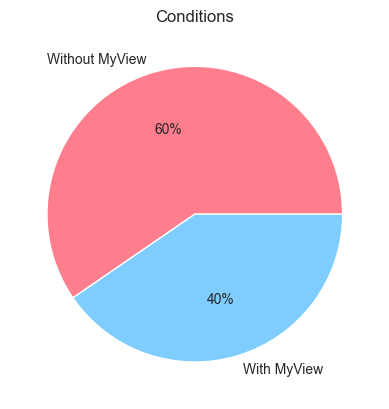

In [250]:
counts = Counter(condition_data)

labels = list(counts.keys())
sizes = list(counts.values())

labels = ["Without MyView", "With MyView"]
pie_plot = plt.pie(sizes, labels=labels, colors=colours, autopct='%.0f%%')
plt.title("Conditions")

output_path = "images/condition_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

Age Distribution

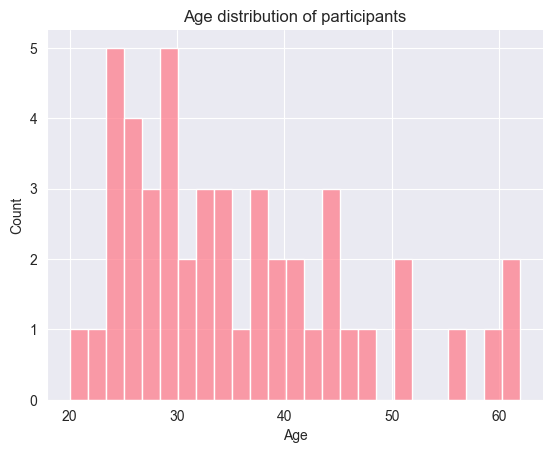

In [251]:
hist_plot = sns.histplot(age_data.dropna(), bins=25, kde=False, color=colours[0], edgecolor = "#FFFFFF")

plt.title("Age distribution of participants")
plt.xlabel("Age")
plt.ylabel("Count")
hist_plot.spines['top'].set_visible(False)
hist_plot.spines['right'].set_visible(False)

output_path = "images/age_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

Gender distribution

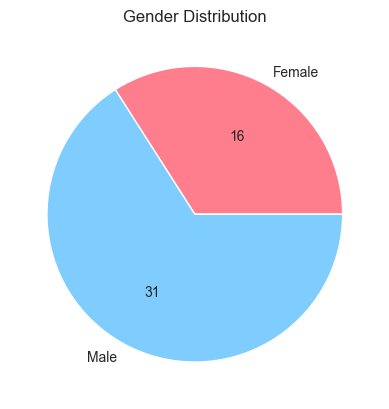

In [252]:
counts = Counter(gender_data)

labels = list(counts.keys())
sizes = list(counts.values())

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d}'.format(v=val)
    return my_format


pie_plot = plt.pie(sizes, labels=labels, colors=colours, autopct=autopct_format(sizes))
plt.title("Gender Distribution")

output_path = "images/gender_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

Occupation

In [253]:
military_count = 0
police_count = 0
fire_count = 0
health_count = 0
security_count = 0
risk_count = 0
it_count = 0
manager_count = 0
finance_count = 0
dispatch_count = 0
other_count = 0

for entry in occupation_data:
    if "military" in entry.lower():
        military_count += 1
    elif "police" in entry.lower() or "polie" in entry.lower():
        police_count += 1
    elif "security" in entry.lower():
        security_count += 1
    elif "fire" in entry.lower():
        fire_count += 1
    elif any(word in entry.lower() for word in ["health", "nurse", "physician", "emt", "rn", "physio", "clinical", "ophthalmic"]):
        health_count += 1
    elif any(word in entry.lower() for word in ["bankkauf", "aml"]):
        finance_count += 1
    elif "risk" in entry.lower():
        risk_count += 1
    elif any(word in entry.lower() for word in ["software", "consultant", "ict", "it"]):
        it_count += 1
    elif "manager" in entry.lower() or "leader" in entry.lower():
        manager_count += 1
    elif "dispatch" in entry.lower():
        dispatch_count += 1
    else:
        other_count += 1
        print(entry)

occupation_counts = {
    "Military": military_count,
    "Police": police_count,
    "Fire": fire_count,
    "Health": health_count,
    "Security": security_count,
    "Risk": risk_count,
    "IT": it_count,
    "Manager": manager_count,
    "Finance": finance_count,
    "Dispatch": dispatch_count,
    "Other": other_count
}
# print("\nMilitary: ", military_count, "\nPolice: ", police_count, "\nFire: ", fire_count, "\nHealth: ", health_count,"\nRisk: ", risk_count, "\nFinance: ", finance_count, "\nManager: ", manager_count, "\nIT: ", it_count, "\nOther: ", other_count)

customer service
Border Customs
Freelancer
Retired, I was caregiver
Modelling and Call Centre
marketing lead


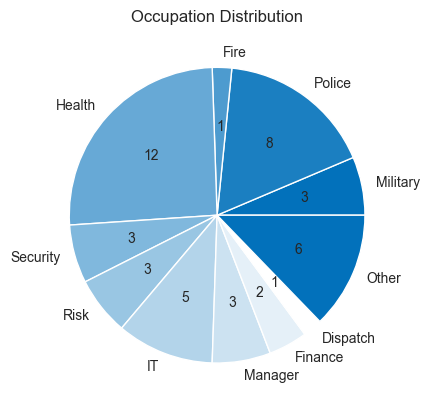

In [254]:
labels = list(occupation_counts.keys())
sizes = list(occupation_counts.values())

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d}'.format(v=val)
    return my_format


pie_plot = plt.pie(sizes, labels=labels, colors=blue_colours, autopct=autopct_format(sizes))
plt.title("Occupation Distribution")

output_path = "images/occupation_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

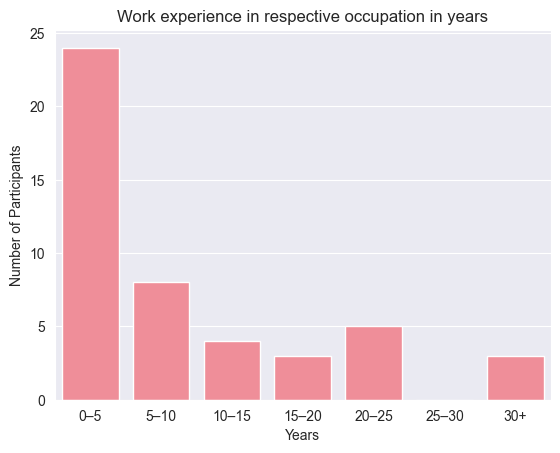

In [255]:
categories = pd.cut(
    experience_data,
    bins=[0,5,10,15,20,25,30,100],
    labels=["0–5","5–10","10–15","15–20","20–25","25–30","30+"]
)

counts = categories.value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values)

plt.title("Work experience in respective occupation in years")
plt.xlabel("Years")
plt.ylabel("Number of Participants")

output_path = "images/experience_in_years_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

Experience distribution

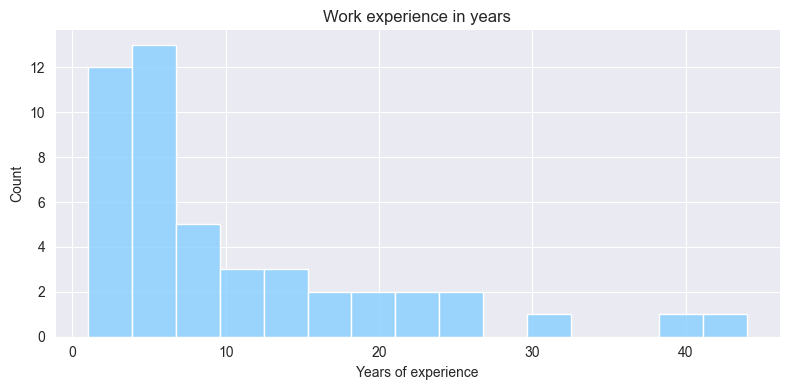

In [256]:
plt.figure(figsize=(8, 4))
exp_numeric = pd.to_numeric(experience_data, errors='coerce').dropna()
exp_plot = sns.histplot(exp_numeric, bins=15, kde=False, color=colours[1], edgecolor='#FFFFFF')
exp_plot.set_title('Work experience in years')
exp_plot.set_xlabel('Years of experience')
exp_plot.set_ylabel('Count')
exp_plot.spines['top'].set_visible(False)
exp_plot.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('images/experience_distribution.png', dpi=150)
plt.show()

Technology affinity

C:\Users\Viktoria\AppData\Local\Temp\ipykernel_29768\672853825.py:8: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  ax = sns.barplot(hue=tech_counts.index.astype(str), y=tech_counts.values, palette=colours)


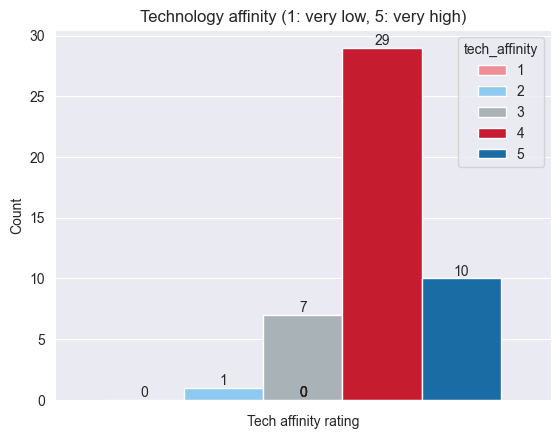

In [257]:
tech_counts = (
    tech_affinity_data
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
    .sort_index()
)

ax = sns.barplot(hue=tech_counts.index.astype(str), y=tech_counts.values, palette=colours)
ax.set_title('Technology affinity (1: very low, 5: very high)')
ax.set_xlabel('Tech affinity rating')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.savefig('images/tech_affinity_distribution.png', dpi=150)
plt.show()

GIS experience and free text summaries

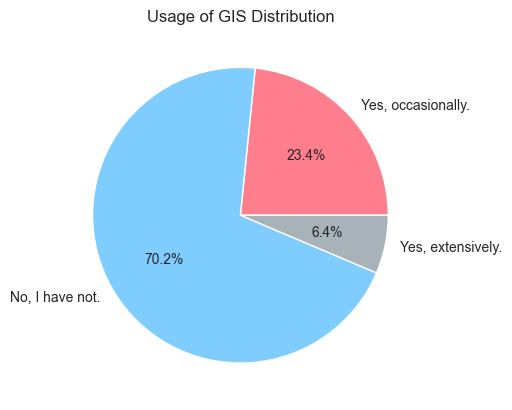

In [258]:
counts = Counter(gis_experience_data)

labels = list(counts.keys())
sizes = list(counts.values())

pie_plot = plt.pie(sizes, labels=labels, colors=colours, autopct="%.1f%%")
plt.title("Usage of GIS Distribution")

output_path = "images/GIS_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

In [259]:
for entry in gis_experience_comment_data:
    print("- ", entry)

-  google maps
-  Yes, i have used GIS tools including Google Maps, QGIS, ArcGIS and other basic mapping applications or navigation analysis.
-  ArcGIS and QGIS
-  I have worked with GIS tools such as Google Maps, QGIS, and other map-based visualization tools for basic spatial analysis and navigation tasks.
-  ArcGIS, QGIS
-  Urban Shift
-  I used it when I studied Environmental Sciences
-  I use a geographic information system to track the location of forest service workers. 
-  ArcGIS online
-  Once as part of our job we were supposed to help people financially due to flooding event in their areas
-  A GIS is a system for working with maps plus data. Instead of just showing locations like a normal map, GIS lets you analyze and layer information about places.


In [260]:
for entry in emergency_experience_data:
    print("-", entry)

- It was a strong thunderstorm, I was verry worried and went home.
- I coordinated the transition to remote operations. My focus was on ensuring that my team was safe and maintaining essential communication with all other relevant departments.
- I have not worked directly in a major emergency such as a storm surge or terrorist attack, but I have experience handling time-sensitive situations and coordinating tasks under pressure.
- I assisted in coordinating evacuations and aid delivery during a major flood in 2024.
- Yes
- I took part in evacuation operation during an earthquake in Turkey
- Yes a storm surge almost two years ago in Durban. It resulted in flooding especially to residents near the beach and living on flat land. We were assigned to offer first aid help
- I have worked during various hurricane's and floods in  operations roles.
- Yes, I have taken part in a smaller regional-level emergency response to severe weather and flooding where I was involved in locating and providi

Task Success Ratio Overall

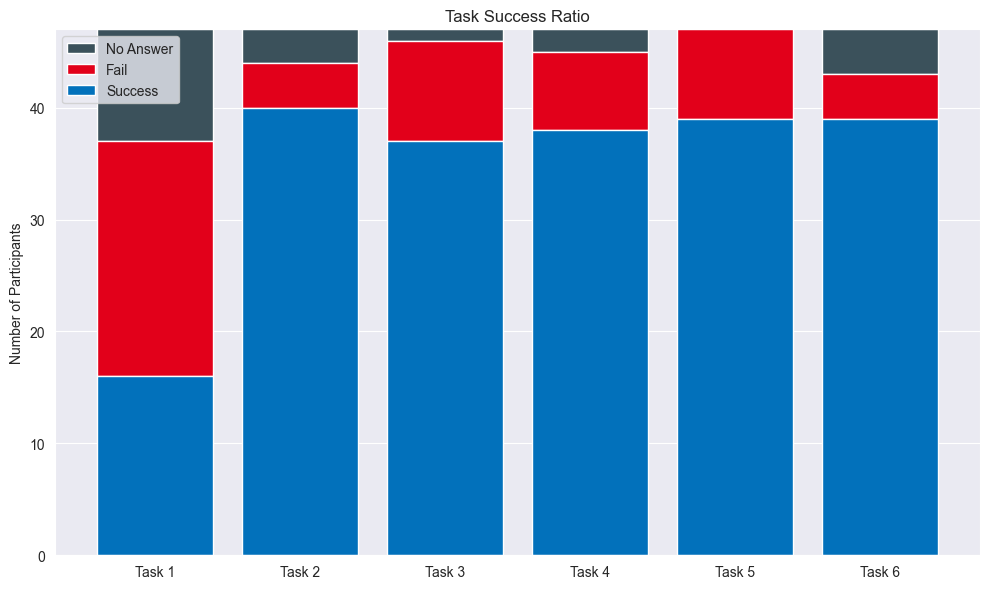

In [261]:
# Data for task success ratio
tasks = ['Task 1', 'Task 2', 'Task 3', 'Task 4', 'Task 5', 'Task 6']
successes = [success1, success2, success3, success4, success5, success6]
fails = [failed1, failed2, failed3, failed4, failed5, failed6]
no_answers = [no_answer1, no_answer2, no_answer3, no_answer4, no_answer5, no_answer6]

# Create stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(tasks, no_answers, bottom=[s + f for s, f in zip(successes, fails)], label='No Answer', color=colours[5])
ax.bar(tasks, fails, bottom=successes, label='Fail', color=colours[3])
ax.bar(tasks, successes, label='Success', color=colours[4])

ax.set_ylabel('Number of Participants')
ax.set_title('Task Success Ratio')
ax.legend()
plt.tight_layout()
plt.savefig('images/task_success_ratio.png', dpi=150)
plt.show()

#TODO: prozentzahlen

Task Success Ratio With vs. Without MyView

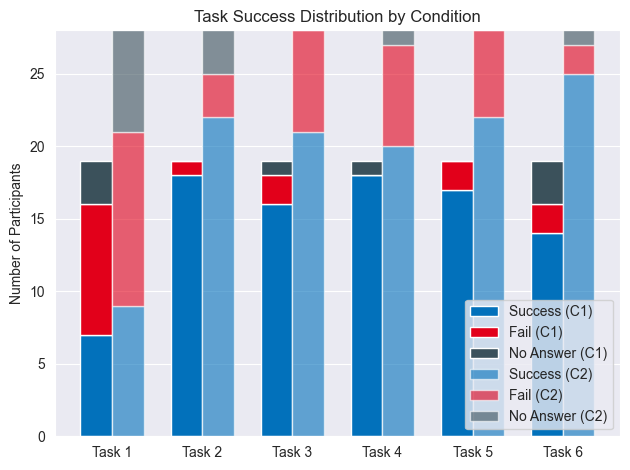

In [262]:
tasks = ['Task 1', 'Task 2', 'Task 3', 'Task 4', 'Task 5', 'Task 6']

# Condition 1
successes_c1 = [success1_cond1, success2_cond1, success3_cond1, success4_cond1, success5_cond1, success6_cond1]
fails_c1 = [failed1_cond1, failed2_cond1, failed3_cond1, failed4_cond1, failed5_cond1, failed6_cond1]
no_answers_c1 = [no_answer1_cond1, no_answer2_cond1, no_answer3_cond1, no_answer4_cond1, no_answer5_cond1, no_answer6_cond1]

# Condition 2
successes_c2 = [success1_cond2, success2_cond2, success3_cond2, success4_cond2, success5_cond2, success6_cond2]
fails_c2 = [failed1_cond2, failed2_cond2, failed3_cond2, failed4_cond2, failed5_cond2, failed6_cond2]
no_answers_c2 = [no_answer1_cond2, no_answer2_cond2, no_answer3_cond2, no_answer4_cond2, no_answer5_cond2, no_answer6_cond2]

tasks = ['Task 1', 'Task 2', 'Task 3', 'Task 4', 'Task 5', 'Task 6']
x = np.arange(len(tasks))  # base positions
width = 0.35  # bar width

# --- Condition 1 ---
plt.bar(x - width/2, successes_c1, width, label='Success (C1)', color=colours[4])
plt.bar(x - width/2, fails_c1, width, bottom=successes_c1, label='Fail (C1)', color=colours[3])
plt.bar(
    x - width/2,
    no_answers_c1,
    width,
    bottom=[s + f for s, f in zip(successes_c1, fails_c1)],
    label='No Answer (C1)',
    color=colours[5]
)

# --- Condition 2 ---
plt.bar(x + width/2, successes_c2, width, label='Success (C2)', color=colours[4], alpha=0.6)
plt.bar(x + width/2, fails_c2, width, bottom=successes_c2, label='Fail (C2)', color=colours[3], alpha=0.6)
plt.bar(
    x + width/2,
    no_answers_c2,
    width,
    bottom=[s + f for s, f in zip(successes_c2, fails_c2)],
    label='No Answer (C2)',
    color=colours[5],
    alpha=0.6
)

# formatting
plt.xticks(x, tasks)
plt.ylabel('Number of Participants')
plt.title('Task Success Distribution by Condition')

plt.legend()
plt.tight_layout()
plt.savefig('images/task_success_by_condition.png', dpi=150)
plt.show()

Task-Time Comparison: Condition 1 (Without MyView) vs. Condition 2 (With MyView)

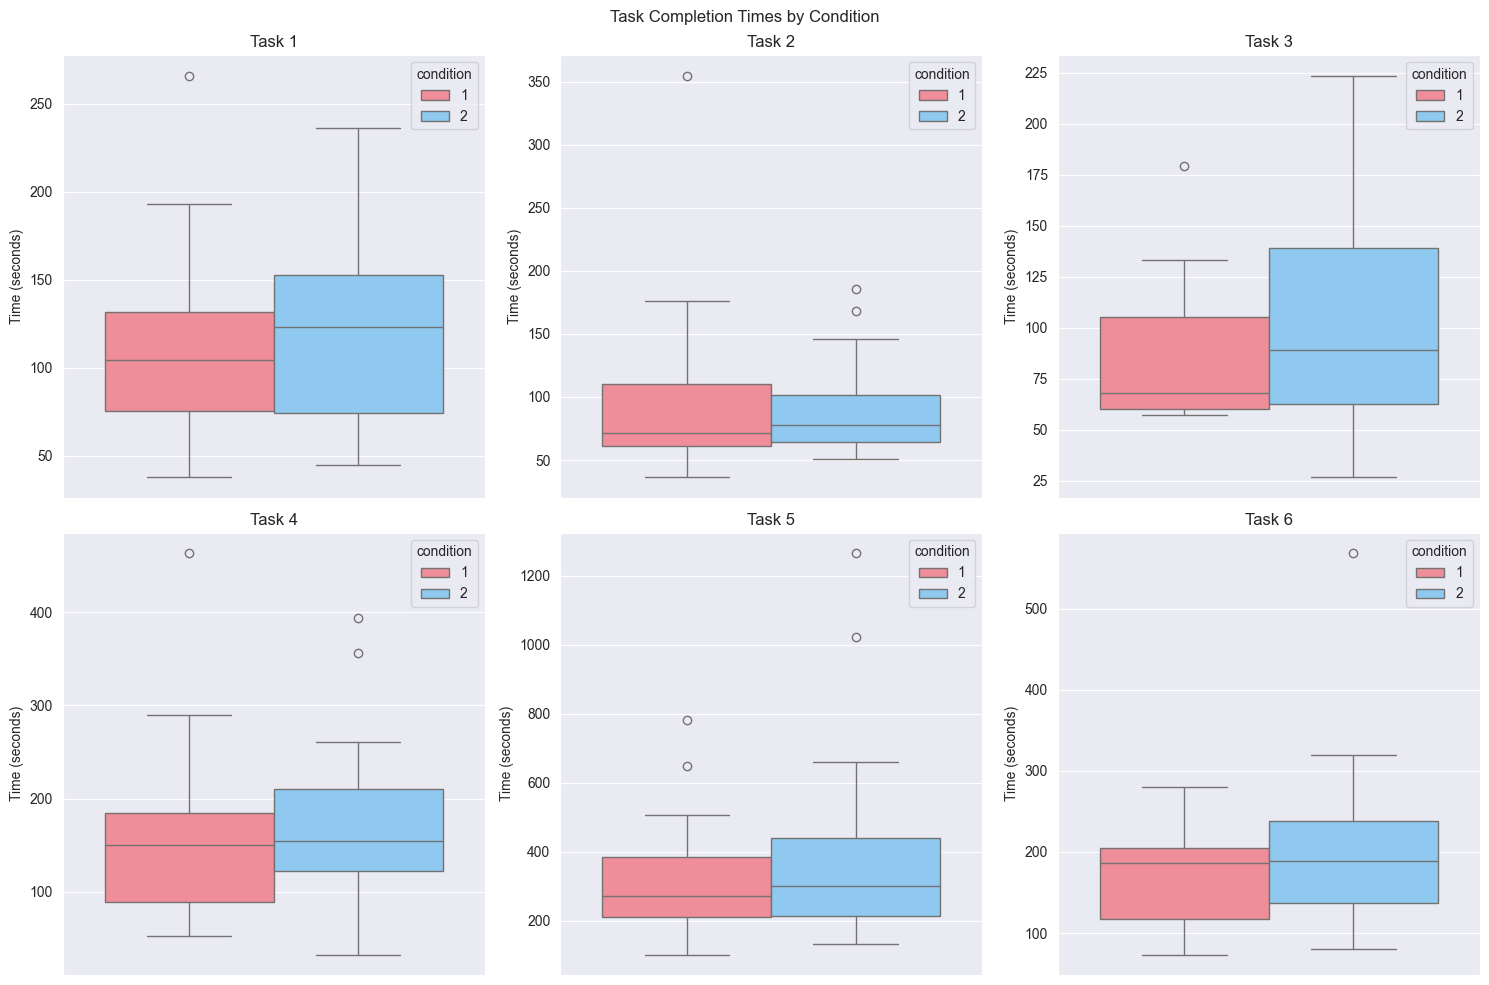

In [263]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Task Completion Times by Condition')

tasks = ['task1', 'task2', 'task3', 'task4', 'task5', 'task6']
for i, task in enumerate(tasks):
    row = i // 3
    col = i % 3
    time_col = f'time_{task}'
    sns.boxplot(data=full_data, hue='condition', y=time_col, ax=axes[row, col], palette=colours[:2])
    axes[row, col].set_title(f'Task {i+1}')
    axes[row, col].set_ylabel('Time (seconds)')

plt.tight_layout()
plt.savefig('images/task_time_comparison_6_plots.png', dpi=150)
plt.show()

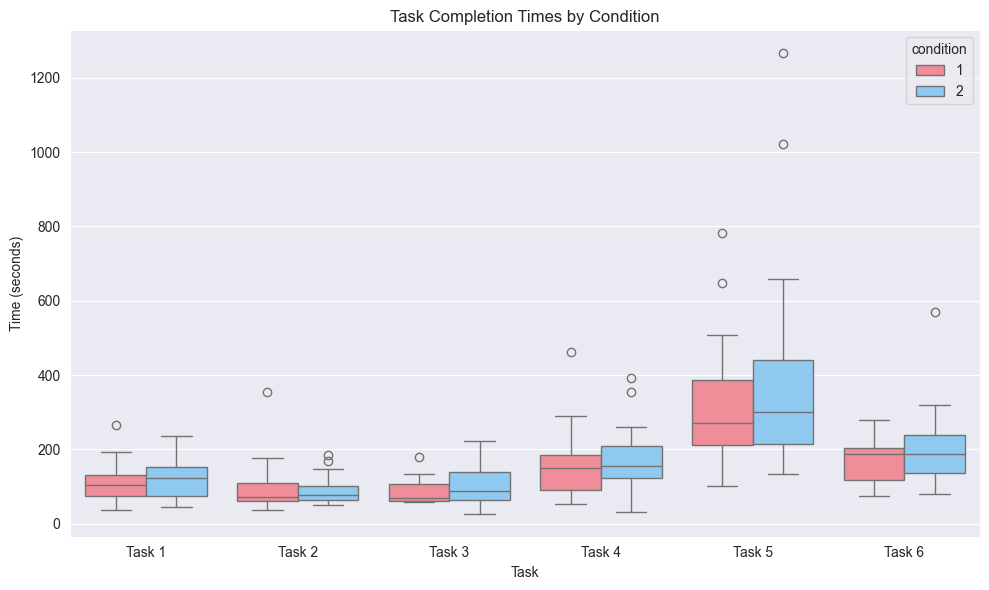

In [266]:
time_cols = [f'time_task{i}' for i in range(1, 7)]

long_df = full_data.melt(
    id_vars='condition',
    value_vars=time_cols,
    var_name='task',
    value_name='time'
)

long_df['task'] = long_df['task'].str.replace('time_task', 'Task ')

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=long_df,
    x='task',
    y='time',
    hue='condition',
    palette=colours[:2]
)

plt.title('Task Completion Times by Condition')
plt.ylabel('Time (seconds)')
plt.xlabel('Task')

plt.tight_layout()
plt.savefig('images/task_time_combined.png', dpi=150)
plt.show()

Task Difficulty Comparison: Condition 1 (Without MyView) vs. Condition 2 (With MyView)

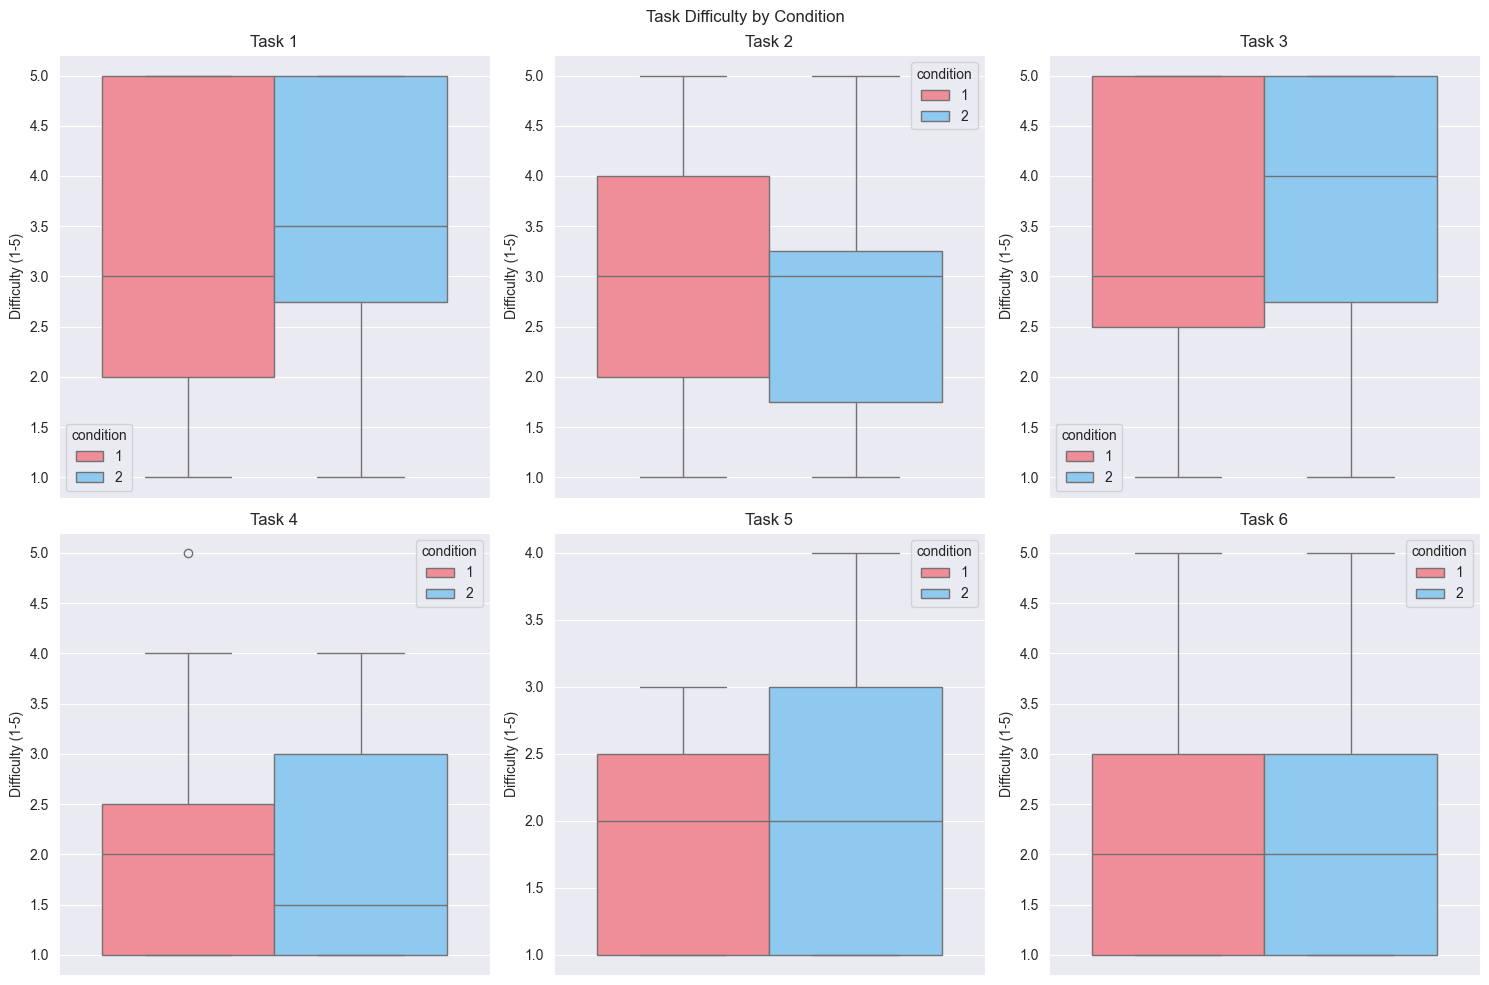

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Task Difficulty by Condition')

def clean_difficulty(series):
    return series.iloc[:, 0].astype(str).str.extract(r'(\d)')[0].astype(int)

task1_difficulty_data = clean_difficulty(task1_difficulty_data)
task2_difficulty_data = clean_difficulty(task2_difficulty_data)
task3_difficulty_data = clean_difficulty(task3_difficulty_data)
task4_difficulty_data = clean_difficulty(task4_difficulty_data)
task5_difficulty_data = clean_difficulty(task5_difficulty_data)
task6_difficulty_data = clean_difficulty(task6_difficulty_data)

tasks = ['task1', 'task2', 'task3', 'task4', 'task5', 'task6']
for i, task in enumerate(tasks):
    row = i // 3
    col = i % 3
    if task == "task1":
        
        difficulty_col = task1_difficulty_data
    elif task == 'task6':
        difficulty_col = task6_difficulty_data
    elif task == 'task2':
        difficulty_col = task2_difficulty_data
    elif task == 'task3':
        difficulty_col = task3_difficulty_data
    elif task == 'task4':
        difficulty_col = task4_difficulty_data
    elif task == 'task5':
        difficulty_col = task5_difficulty_data
    sns.boxplot(data=full_data, hue='condition', y=difficulty_col, ax=axes[row, col], palette=colours[:2])
    axes[row, col].set_title(f'Task {i+1}')
    axes[row, col].set_ylabel('Difficulty (1-5)')

plt.tight_layout()
plt.savefig('images/task_difficulty_comparison.png', dpi=150)

plt.show()

Task questions - myview usage etc.

C:\Users\Viktoria\AppData\Local\Temp\ipykernel_29768\609057196.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=effectiveness_data, palette=colours)
C:\Users\Viktoria\AppData\Local\Temp\ipykernel_29768\609057196.py:3: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.countplot(x=effectiveness_data, palette=colours)


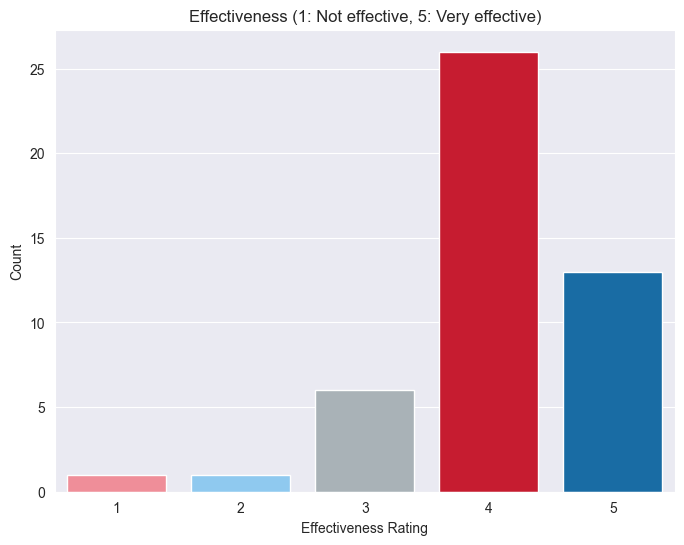

In [ ]:
# Effectiveness
plt.figure(figsize=(8, 6))
sns.countplot(x=effectiveness_data, palette=colours)
plt.title('Effectiveness (1: Not effective, 5: Very effective)')
plt.xlabel('Effectiveness Rating')
plt.ylabel('Count')
plt.savefig('images/effectiveness.png', dpi=150)
plt.show()


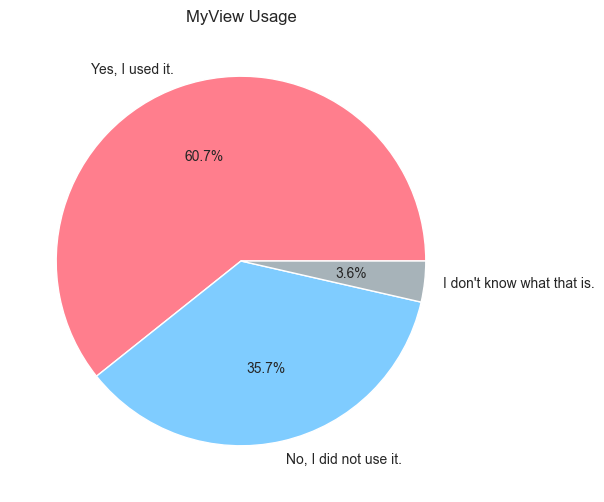

In [ ]:

# Used MyView
counts = used_myview_data.value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colours)
plt.title('MyView Usage')
plt.savefig('images/used_myview.png', dpi=150)
plt.show()


C:\Users\Viktoria\AppData\Local\Temp\ipykernel_29768\2621033571.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Viktoria\AppData\Local\Temp\ipykernel_29768\2621033571.py:15: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(


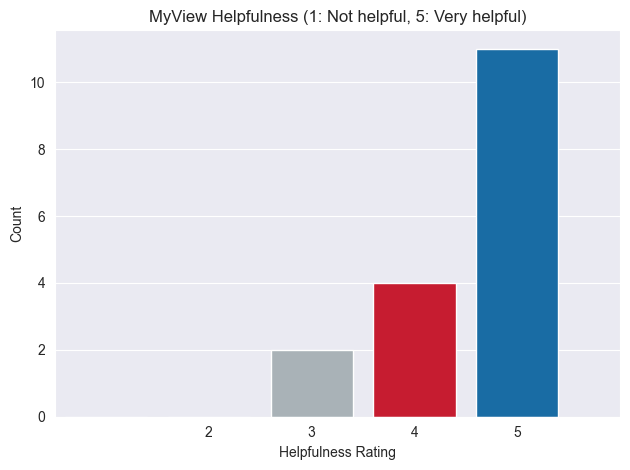

In [ ]:

# MyView Helpfulness (only for those who used it)
used_data = full_data[used_myview_data == 'Yes, I used it.']
helpfulness_data = used_data['myview_helpfulness']

clean_helpfulness_data = (
    helpfulness_data
    .astype(str)
    .str.split(" - ").str[0]
    .astype(int)
)

counts = clean_helpfulness_data.value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)


sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=colours
)

plt.title('MyView Helpfulness (1: Not helpful, 5: Very helpful)')
plt.xlabel('Helpfulness Rating')
plt.ylabel('Count')
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig('images/myview_helpfulness.png', dpi=150)
plt.show()

C:\Users\Viktoria\AppData\Local\Temp\ipykernel_29768\2682886560.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Viktoria\AppData\Local\Temp\ipykernel_29768\2682886560.py:13: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(


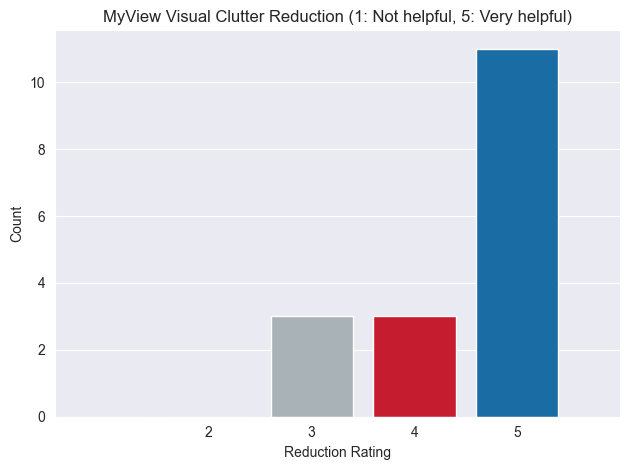

In [ ]:

clutter_reduction_data = used_data['myview_clutter_reduction']

clean_clutter_reduction_data = (
    clutter_reduction_data
    .astype(str)
    .str.split(" - ").str[0]
    .astype(int)
)

counts = clean_clutter_reduction_data.value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)


sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=colours
)

plt.title('MyView Visual Clutter Reduction (1: Not helpful, 5: Very helpful)')
plt.xlabel('Reduction Rating')
plt.ylabel('Count')
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig('images/myview_clutter_reduction.png', dpi=150)
plt.show()

SUS-Score Condition 1 vs. Condition 2

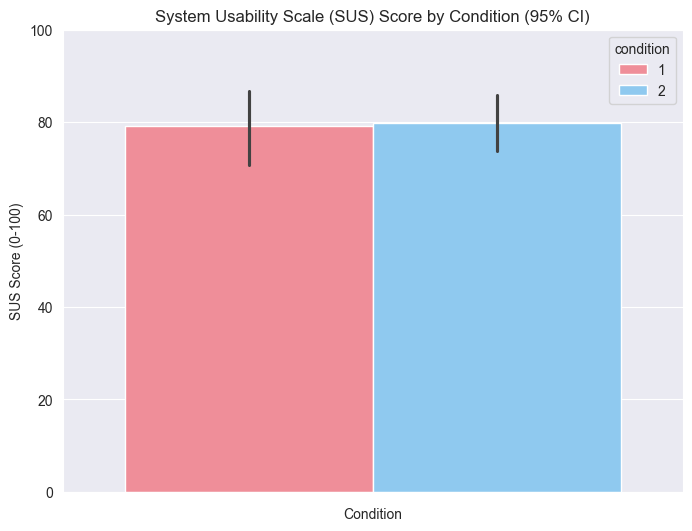

In [ ]:
# SUS-Score Overall vs. Condition 1 vs. Condition 2
# Calculate SUS score: sum of items with odd reversed (5 - value), even as is, then * 2.5
sus_odd = ['sus_1', 'sus_3', 'sus_5', 'sus_7', 'sus_9']
sus_even = ['sus_2', 'sus_4', 'sus_6', 'sus_8', 'sus_10']

full_data['sus_score'] = (
    full_data[sus_odd].apply(lambda x: x.str[0].astype(int)).sum(axis=1) + 
    (5 - full_data[sus_even].apply(lambda x: x.str[0].astype(int))).sum(axis=1)
) * 2.5

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(data=full_data, hue='condition', y='sus_score', palette=colours[:2], errorbar=('ci', 95))
plt.title('System Usability Scale (SUS) Score by Condition (95% CI)')
plt.xlabel('Condition')
plt.ylabel('SUS Score (0-100)')
plt.ylim(0, 100)
plt.savefig('images/sus_score_comparison.png', dpi=150)
plt.show()

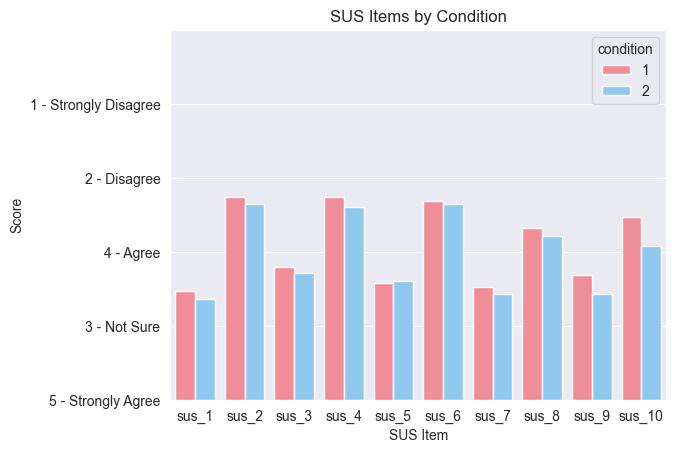

In [ ]:
sus_cols = [f"sus_{i}" for i in range(1, 11)]

sus_long = full_data.melt(
    id_vars="condition",
    value_vars=sus_cols,
    var_name="sus_item",
    value_name="score"
)

sns.barplot(
    data=sus_long,
    x="sus_item",
    y="score",
    hue="condition",
    palette=colours[:2],
    errorbar=None
)

plt.title('SUS Items by Condition')
plt.xlabel('SUS Item')
plt.ylabel('Score')
plt.ylim(0, 5)  # assuming Likert scale

plt.savefig('images/sus_items_comparison.png', dpi=150)
plt.show()

NASA-TLX Score Condition 1 vs. Condition 2

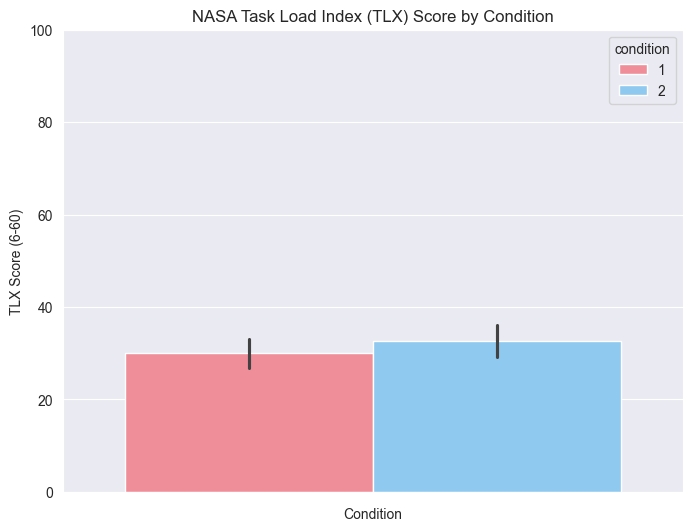

In [ ]:
# NASA-TLX Score Overall vs. Condition 1 vs. Condition 2
tlx_cols = ['tlx_mental', 'tlx_physical', 'tlx_temporal', 'tlx_performance', 'tlx_effort', 'tlx_frustration']
full_data['tlx_score'] = full_data[tlx_cols].apply(lambda x: x.str.split(' - ').str[0].astype(int)).sum(axis=1)

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(data=full_data, hue='condition', y='tlx_score', palette=colours[:2])
plt.title('NASA Task Load Index (TLX) Score by Condition')
plt.xlabel('Condition')
plt.ylabel('TLX Score (6-60)')
plt.ylim(0, 100)
plt.savefig('images/tlx_score_comparison.png', dpi=150)
plt.show()

In [ ]:
tlx_cols = [
    'tlx_mental', 'tlx_physical', 'tlx_temporal',
    'tlx_performance', 'tlx_effort', 'tlx_frustration'
]

tlx_long = full_data.melt(
    id_vars="condition",
    value_vars=tlx_cols,
    var_name="dimension",
    value_name="score"
)

tlx_long["score"] = (
    tlx_long["score"]
    .astype(str)
    .str.split(" - ").str[0]
    .astype(float)
)

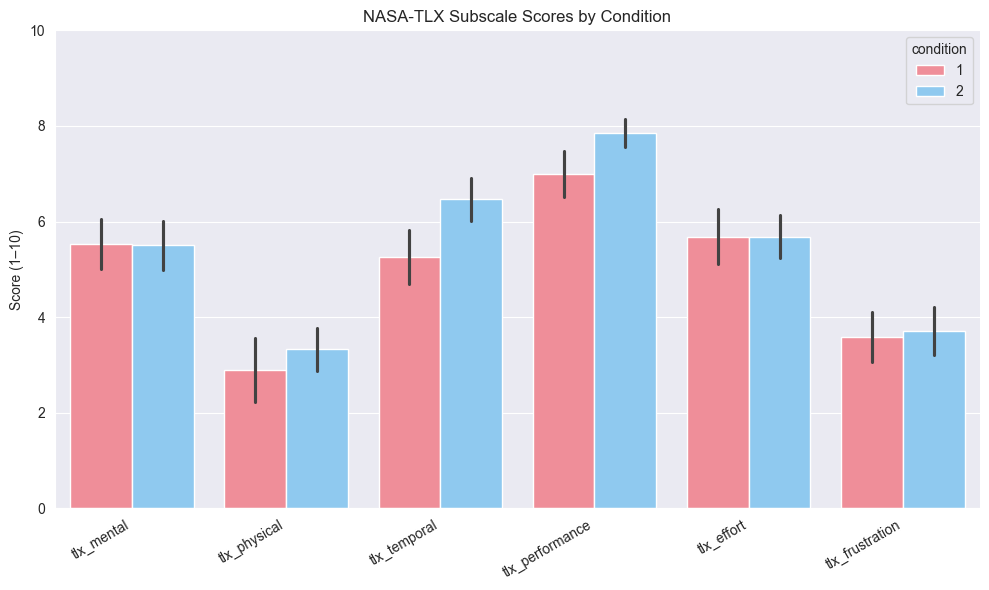

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=tlx_long,
    x="dimension",
    y="score",
    hue="condition",
    palette=colours[:2],
    errorbar="se"
)

ax.set_title("NASA-TLX Subscale Scores by Condition")
ax.set_xlabel("")
ax.set_ylabel("Score (1–10)")
ax.set_ylim(0, 10)

plt.xticks(rotation=30, ha="right")

# clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/tlx_subscales_barplot.png', dpi=150)
plt.show()

Feedback

In [ ]:
print("Suggestions:")
for entry in feedback_improvements_data:
    if entry != "":
        print("-", entry)

Suggestions:
- I think that the zoom in and out should not be too sensitive
- bigger font
- No, it's very easy to use.
- Not really I did like the application a lot. 
- I should have spent more time at beginning playing with the mao and its features
- Control the zoom options and make it easy to move left, right, up, down
- Extra time to learn more about the map prior to performing the tasks will be helpful
- when searching for a ship; it would be automatically highlighted on the map 
- NO
- No suggestions come to mind, I think it's great. A really simple way to be able to view, modify and add data to a map.
- I think that the tasks were straight forward enough, I think it was just the time constraint. I do think that with a couple of extra minutes more would of meant better execution overall. I do agree that the system is quite straight forward and helpful enough.
- NOT SURE , I STILL NEED TO LEARN MORE
- I just made a new test incident and I see the incident on the right side but it 

In [ ]:
print("Other layer information:")
for entry in feedback_improvements_data:
    print("-", entry)
for entry in other_layers_data:
    print("-", entry)

Other layer information:
- I think that the zoom in and out should not be too sensitive
- bigger font
- No, it's very easy to use.
- Not really I did like the application a lot. 
- I should have spent more time at beginning playing with the mao and its features
- Control the zoom options and make it easy to move left, right, up, down
- Extra time to learn more about the map prior to performing the tasks will be helpful
- when searching for a ship; it would be automatically highlighted on the map 
- NO
- No suggestions come to mind, I think it's great. A really simple way to be able to view, modify and add data to a map.
- I think that the tasks were straight forward enough, I think it was just the time constraint. I do think that with a couple of extra minutes more would of meant better execution overall. I do agree that the system is quite straight forward and helpful enough.
- NOT SURE , I STILL NEED TO LEARN MORE
- I just made a new test incident and I see the incident on the right 

In [ ]:
print("Issues:")
for entry in feedback_issues_data:
    print("-", entry)

Issues:
- no issues
- Making an incident. The app made a different area as mine.
- During the last task, the map took time to load and I was not able to view the locations clearly, I also struggled and find myself little confused to perform last task. 
- No difficulties.
- I didnt have any issues other than managing the app on the survey site
- as I said I do believe more time is required at beginning to get used to it
- It initially took too long to load
- Time allocated was rather short. Hence, unable to explore the full functionality of the map.
- NO
- yes, I wasn't able to determine which open ports or what have you, there were two symbols to count and I couldn't determine which was which. 
- No other issues apart from minor issues already reported in prior questions.
- No issues as such, That time goes down quicker than expected but i tried :)
- not experienced enough
- The map problem like i explained
- dont think so 
- I was frustrated and anxious by the three minute timer. It s

Statistische Tests